<a href="https://colab.research.google.com/github/BridgingAISocietySummerSchools/Python-for-Data-Science-Workshop/blob/main/02_advanced_self_learning/10_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔎 Notebook 10 — Exploratory Data Analysis

> **Advanced & Self-Learning Track — Notebook 10 of 14** · **Estimated time:** 50–60 min · **Difficulty:** Intermediate
>
> This track is the self-paced deep-dive of the course; the 90-minute live **Introduction Session** lives in `01_introduction/`.

Three notebooks ago you learned to *hold* a table (pandas), then to *repair* one (cleaning), then to *draw* one (matplotlib). None of those told you what to **ask**.

Exploratory Data Analysis is the part of the job where you sit down with a dataset you did not create and find out what is actually in it — before you fit a single model. It is not a gallery of plots. It is an interrogation: you form an expectation, you check it, and you pay close attention to the moments when the data refuses to agree with you. Those moments are the whole point.

This notebook runs one complete investigation on a small, real dataset, and gives you a checklist you can reuse on any table you ever meet.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Run a **reusable EDA workflow** — provenance → structure → sanity → univariate → bivariate → grouped → write-up.
2. Read `.shape`, `.dtypes` and `.describe()` as *evidence*, not as decoration, and say what one row means.
3. Judge a distribution by **shape, centre, spread and skew**, and check **class balance** before modelling.
4. Read a **correlation matrix** honestly — including what correlation cannot see.
5. Use `groupby` to find which features **separate the groups** you care about.
6. Recognise a **confounded aggregate**: when the whole-table answer and the per-group answer disagree.
7. Write findings up as *what we learned / what to check next / what this data cannot tell us*.

## 📋 Prerequisites

- **Notebook 7 — Pandas Essentials**: selection, filtering, `groupby`, `.describe()`.
- **Notebook 8 — Data Cleaning and Preprocessing**: missing values, sentinel codes, duplicates.
- **Notebook 9 — Visualisation with Matplotlib**: the `fig, ax` pattern, histograms, scatter, box plots, subplots.

We will *use* all of that fluently rather than re-explain it. If a line of pandas or matplotlib below is unfamiliar, that notebook is the place to look it up. Everything genuinely new here is about **method**: what to look at, in what order, and how to avoid fooling yourself.

## 1. What EDA is — and why it comes before modelling

A model is a machine for turning a table into predictions. It has no opinion about whether the table is any good. If a column is half sentinel values, if two features are secretly the same measurement, if 95 % of your rows belong to one class — the model will happily absorb all of it and hand you a number that looks like success.

EDA is the step where *you* form the opinion. Concretely, you are doing three things:

| You are… | Which looks like… |
|---|---|
| **Building a mental model** of the data | "one row is one wine sample; proline is in the hundreds; there are three groups" |
| **Testing expectations** | "these two chemical measurements should move together — do they?" |
| **Hunting for surprises** | "why is that relationship *negative*? I expected positive." |

The third one is the valuable one. Confirmations are cheap; a surprise is the data telling you something you did not put there yourself.

### 🧭 The reusable EDA checklist

Use this on every dataset, in this order. The order matters: each step protects the next.

1. **Provenance.** Where is this from, who measured it, when, and **what does one row represent?** If you cannot answer the last question, stop and find out.
2. **Structure.** `.shape`, `.dtypes`, `.head()`. How many rows, how many columns, what type is each, and are the types the ones you expected?
3. **Sanity.** Missing values, duplicates, impossible values, sentinel codes (`-999`, `0` for "unknown"), units.
4. **One variable at a time.** For each interesting column: shape of the distribution, centre, spread, skew, outliers.
5. **Two variables at a time.** Scatter plots, a correlation matrix, and every feature against the thing you eventually want to predict.
6. **Split by group.** Re-run the interesting findings *within* subgroups. Anything that does not survive this step was never a finding.
7. **Write it down.** What you learned, what you would check next, and what this data fundamentally cannot tell you.

> 🧰 Steps 2 and 3 never vary from dataset to dataset, so Section 9 turns them into a function you can paste into your next project. Steps 4–7 are judgement, and judgement does not automate.

> ⚠️ **The one rule.** EDA is where you are *allowed* to look at everything. Once you start modelling, looking at the test set becomes cheating (Notebook 11 makes that precise). So do your looking now — thoroughly, and with a notebook that records what you saw.

## 2. Setup and the dataset

Charts in this course follow the **Bridging AI & Society** brand palette, defined once in the setup cell below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# --- Bridging AI & Society course plot style -------------------------------
BAS_BLUE = "#416bcc"   # brand accent (lapis blue) — primary series
BAS_INK  = "#1c2025"   # brand ink — text/edges where needed
# supporting colours, chosen to sit well next to the lapis accent:
BAS_AMBER  = "#d9822b"   # secondary series / contrast
BAS_GREEN  = "#3a9e6e"   # "good" / positive
BAS_RED    = "#c8504f"   # "bad" / warnings / errors
BAS_PURPLE = "#7a5fb5"   # tertiary series
BAS_GREY   = "#8a919c"   # de-emphasised / reference lines
BAS_PALETTE = [BAS_BLUE, BAS_AMBER, BAS_GREEN, BAS_RED, BAS_PURPLE, BAS_GREY]

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=BAS_PALETTE)
plt.rcParams.update({
    "figure.figsize"   : (8, 5),
    "figure.dpi"       : 100,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
})

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

# One colour per cultivar, reused in every chart below so the reader
# never has to re-learn the legend.
CULTIVAR_COLORS = {"class_0": BAS_BLUE, "class_1": BAS_AMBER, "class_2": BAS_PURPLE}

print("Setup complete — pandas", pd.__version__, "| matplotlib", plt.matplotlib.__version__)

Setup complete — pandas 2.3.3 | matplotlib 3.9.4


### Step 1 of the checklist: provenance

We use the **Wine recognition dataset**, which ships *inside* scikit-learn — no download, no network, so this notebook runs offline in Colab.

- **Origin:** the UCI Machine Learning Repository ("Wine"), from work by Forina *et al.* Data collected in Italy.
- **What was measured:** a chemical analysis of wines grown in the *same region of Italy*, from **three different cultivars** (grape varieties).
- **What one row is:** **one physical wine sample.** Thirteen numbers describing its chemistry, plus a label saying which of the three cultivars it came from.
- **Size:** 178 samples, 13 features, 3 classes.
- **Units:** honestly — the original documentation is thin. `alcohol` is percent by volume; `magnesium` and `proline` are concentrations in the tens-to-thousands range; `od280/od315_of_diluted_wines`, `hue` and `color_intensity` are unitless optical measurements. Where the unit is not documented, the correct move is to **say so** rather than invent one. You will meet this constantly with real data.

We load it as a DataFrame immediately (`as_frame=True`), and add a readable `cultivar` column next to the numeric `target` code.

In [2]:
wine = load_wine(as_frame=True)

df = wine.frame.copy()                     # 13 features + integer 'target'
df["cultivar"] = pd.Categorical.from_codes(df["target"], wine.target_names)

FEATURES = [c for c in wine.feature_names]  # the 13 measured chemical features

print("Feature columns:")
for i, name in enumerate(FEATURES, start=1):
    print(f"  {i:2d}. {name}")
print("\nTarget classes:", ", ".join(wine.target_names))
print("One row =", "one wine sample")
print("Rows:", len(df), "| columns:", df.shape[1])

Feature columns:
   1. alcohol
   2. malic_acid
   3. ash
   4. alcalinity_of_ash
   5. magnesium
   6. total_phenols
   7. flavanoids
   8. nonflavanoid_phenols
   9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline

Target classes: class_0, class_1, class_2
One row = one wine sample
Rows: 178 | columns: 15


## 3. Know your table (checklist steps 2 and 3)

Four commands, and you already know more than most people who will use this data.

In [3]:
print("shape (rows, columns):", df.shape)
print()
print(df.dtypes)

shape (rows, columns): (178, 15)

alcohol                          float64
malic_acid                       float64
ash                              float64
alcalinity_of_ash                float64
magnesium                        float64
total_phenols                    float64
flavanoids                       float64
nonflavanoid_phenols             float64
proanthocyanins                  float64
color_intensity                  float64
hue                              float64
od280/od315_of_diluted_wines     float64
proline                          float64
target                             int64
cultivar                        category
dtype: object


**Interpreting that.** 178 rows × 15 columns: the 13 chemical features, the integer `target`, and the `cultivar` label we just added. Every feature is `float64` — plausible for laboratory measurements. `target` is `int64`, and this is the first thing worth flagging: **it is a code, not a quantity.** Class 2 is not "twice" class 1. In Section 5 we will see exactly what goes wrong when you forget that.

`.head()` is not a formality — it is where you check that the numbers *look like* the thing they claim to be.

In [4]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


Nothing alarming: alcohol values near 13–14 (% vol, believable for wine), proline in the hundreds, `od280/od315` around 2–4. Column magnitudes differ by *three orders of magnitude* — remember that; it comes back in a moment.

Now the summary statistics. `.describe()` is eight numbers per column and almost nobody reads all of them.

In [5]:
df[FEATURES].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


**How to actually read this table.** Go column by column of the *output*, not row by row:

- **`count` = 178 everywhere.** No feature has missing entries. Good — and note that this is information, not just an absence of a problem.
- **`mean` vs `50%` (median).** Where they are close, the distribution is roughly symmetric (`ash`: 2.37 vs 2.36). Where the mean sits clearly above the median, there is a right tail — `malic_acid` (2.34 vs 1.87), `color_intensity` (5.06 vs 4.69), `proline` (746.89 vs 673.50). That is skew, visible without a single plot.
- **`std` relative to `mean`.** `ash` has mean 2.37 and std 0.27 — barely varies, so it can hardly distinguish anything. `proline` has mean 746.89 and std 314.91 — it *moves*. Features that do not vary cannot be informative.
- **`min` / `max`.** Sanity check: `alcohol` runs 11.03 → 14.83, exactly the range wine lives in. No negatives, no zeros where zero would be impossible, no `-999`. This dataset is unusually clean.
- **Scale.** `proline` spans hundreds; `hue` spans 0.48–1.71. Any algorithm that measures distances (k-NN, SVM, k-means) — or that takes gradient-descent steps across all features at once — would be dominated entirely by `proline`. That is *why* the `StandardScaler` you met in Notebook 8 belongs in front of such a model, and why Notebook 12 makes it the first step of a pipeline. The decision is taken here, in the EDA, before any model exists.

Let us finish the sanity step explicitly.

In [6]:
print("Missing values per column, total:", int(df.isna().sum().sum()))
print("Exact duplicate rows:", int(df.duplicated().sum()))
print()
# Sentinel hunt: values that are suspiciously round or negative in a
# non-negative measurement. A quick, blunt, always-worth-running check.
suspicious = {c: int(((df[c] <= 0) | (df[c] == -999)).sum()) for c in FEATURES}
print("Columns with values <= 0 or == -999:",
      {k: v for k, v in suspicious.items() if v > 0} or "none")

Missing values per column, total: 0
Exact duplicate rows: 0

Columns with values <= 0 or == -999: none


Zero missing, zero duplicates, no sentinels. **Be suspicious of clean data.** A dataset this tidy has almost always been curated: this one has been a teaching and benchmarking dataset for decades, and whatever was awkward about the original lab notebook was smoothed away long before it reached us. Real data at work will not look like this.

That is worth saying out loud, because it is a limit on what we can conclude — and it goes in the write-up at the end.

## 4. One variable at a time (checklist step 4)

A histogram answers three questions at once: *where is the mass, how wide is it, and is it symmetric?* Six features, six panels, one glance.

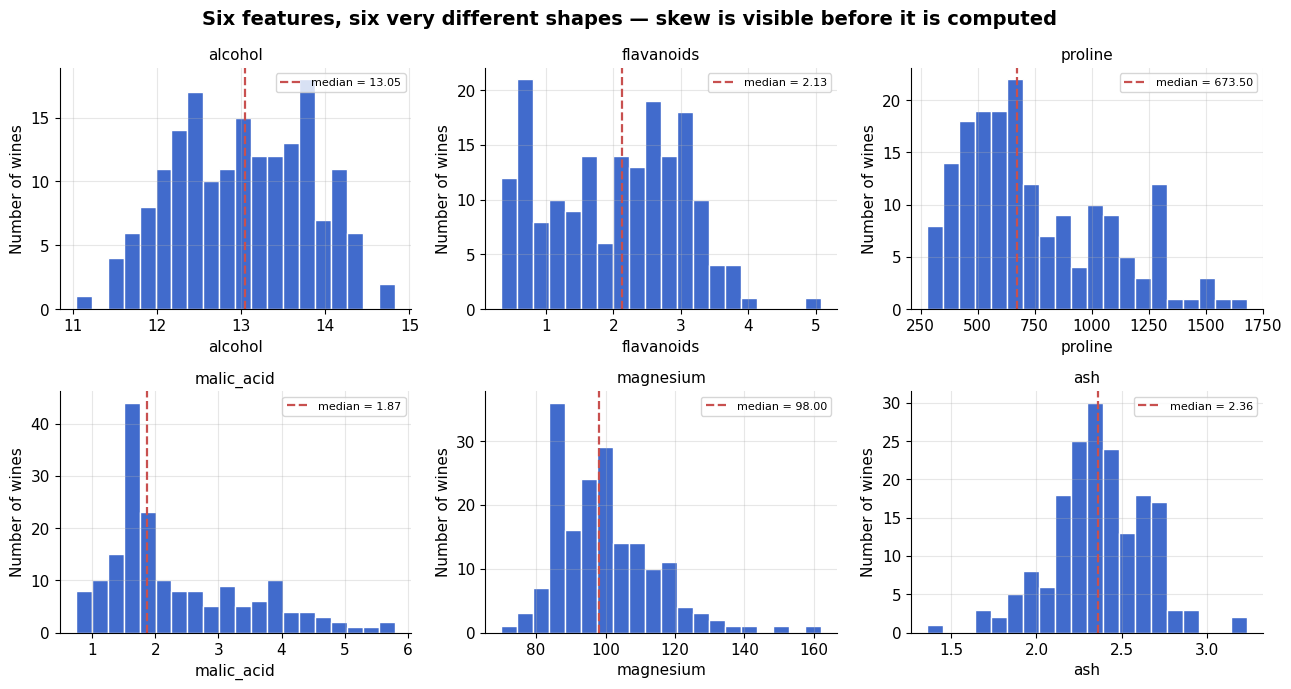

In [7]:
show = ["alcohol", "flavanoids", "proline", "malic_acid", "magnesium", "ash"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fig.suptitle("Six features, six very different shapes — skew is visible before it is computed",
             fontsize=14, fontweight="bold")

for ax, col in zip(axes.ravel(), show):
    ax.hist(df[col], bins=20, color=BAS_BLUE, edgecolor="white")
    ax.axvline(df[col].median(), color=BAS_RED, linestyle="--", linewidth=1.6,
               label=f"median = {df[col].median():.2f}")
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Number of wines")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Reading the six panels.**

- `alcohol` — a broad, roughly symmetric hump. Nothing odd; everything is where wine should be.
- `flavanoids` — wide, flat, arguably **two humps**. A histogram with more than one peak is a strong hint that the sample is a *mixture of groups*. Hold that thought.
- `proline` — clear right tail: most wines in the 400–800 range, a thinner stream running out past 1400.
- `malic_acid` — the same story, more pronounced.
- `magnesium` — a compact bulk plus a handful of high values. Those extreme points are the reason its mean (99.74) sits above its median (98.00).
- `ash` — narrow and symmetric. Almost all the mass in 2.0–2.8. A feature that barely varies is a feature that barely informs.

Now put a number on the asymmetry instead of arguing about it.

In [8]:
skew = df[FEATURES].skew().sort_values(ascending=False).round(2)
print("Skewness (0 = symmetric, > 0 = right tail, < 0 = left tail)\n")
print(skew)

Skewness (0 = symmetric, > 0 = right tail, < 0 = left tail)

magnesium                       1.10
malic_acid                      1.04
color_intensity                 0.87
proline                         0.77
proanthocyanins                 0.52
nonflavanoid_phenols            0.45
alcalinity_of_ash               0.21
total_phenols                   0.09
flavanoids                      0.03
hue                             0.02
alcohol                        -0.05
ash                            -0.18
od280/od315_of_diluted_wines   -0.31
dtype: float64


**Interpretation.** `magnesium` (1.10) and `malic_acid` (1.04) have the longest right tails; `od280/od315_of_diluted_wines` (−0.31) leans slightly the other way; `flavanoids` (0.03) and `hue` (0.02) are essentially symmetric — which tells you that *flavanoids' two humps are not skew*, they are structure. Skew is a one-number summary and it cannot see bimodality. Neither can the mean. This is why you plot.

Rules of thumb, worth memorising: |skew| < 0.5 is "near-symmetric", 0.5–1 "moderate", > 1 "strong". Strong skew is a reason to consider a log transform (Notebook 8) and a reason to prefer the **median** as your summary of centre.

### Class balance — check it before you model, not after

The target is categorical, so the tool is `value_counts()`, not `.describe()`.

           n  share_%
cultivar             
class_0   59     33.1
class_1   71     39.9
class_2   48     27.0


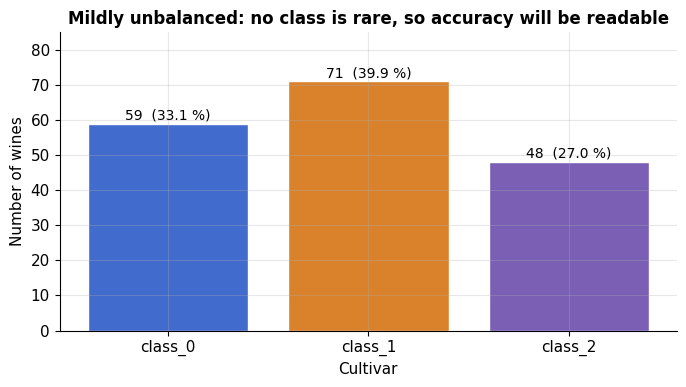

In [9]:
counts = df["cultivar"].value_counts().sort_index()
shares = (counts / len(df) * 100).round(1)

print(pd.DataFrame({"n": counts, "share_%": shares}))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index.astype(str), counts.values,
       color=[CULTIVAR_COLORS[c] for c in counts.index.astype(str)],
       edgecolor="white")
for i, (n, s) in enumerate(zip(counts.values, shares.values)):
    ax.text(i, n + 1.2, f"{n}  ({s} %)", ha="center", fontsize=10)

ax.set_title("Mildly unbalanced: no class is rare, so accuracy will be readable",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Cultivar")
ax.set_ylabel("Number of wines")
ax.set_ylim(0, 85)
plt.tight_layout()
plt.show()

**Interpretation.** 59 / 71 / 48 wines for `class_0` / `class_1` / `class_2`, i.e. 33.1 % / 39.9 % / 27.0 %. That is *mild* imbalance, and it matters for one concrete reason: it sets the score a useless model gets for free. Always predicting the largest class (`class_1`) would be right **39.9 %** of the time. So 40 % accuracy is not a result — it is the floor.

> 🔭 **Forward pointer to Notebook 11.** Now imagine the split were 97 / 2 / 1. The always-predict-the-majority model scores 97 % accuracy while never once identifying the rare class — which is usually the class you built the system to find (the fraud, the tumour, the failure). That is why Notebook 11 replaces accuracy with **precision, recall and the confusion matrix**, and Notebook 12 computes them inside a pipeline. The reason those metrics exist is the `value_counts()` you just ran.

### Exercise 10.1 — Profile a feature you have not met

`alcalinity_of_ash` has not appeared in any chart yet. Profile it properly:

1. Print its count, mean, median, std, min and max.
2. Print its skewness.
3. Draw a histogram (20 bins, `BAS_BLUE`) with a dashed `BAS_RED` line at the median, labelled axes and a title that states the takeaway.
4. Write one sentence describing the shape.

In [10]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
col = "alcalinity_of_ash"

print(df[col].describe()[["count", "mean", "50%", "std", "min", "max"]].round(2))
print("skew:", round(df[col].skew(), 2))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df[col], bins=20, color=BAS_BLUE, edgecolor="white")
ax.axvline(df[col].median(), color=BAS_RED, linestyle="--", linewidth=1.8,
           label=f"median = {df[col].median():.2f}")
ax.set_title("Alcalinity of ash is near-symmetric and tightly concentrated",
             fontsize=12, fontweight="bold")
ax.set_xlabel("alcalinity_of_ash")
ax.set_ylabel("Number of wines")
ax.legend()
plt.tight_layout()
plt.show()
```

**Reasoning.** Mean 19.49 versus median 19.50 — indistinguishable, so no meaningful asymmetry, and the skewness of **0.21** confirms it (well inside the "near-symmetric" band of |skew| < 0.5). The range is 10.60 to 30.00 with a standard deviation of 3.34, so the bulk of the wines sit within roughly ±17 % of the centre: a single, fairly tight hump with no second peak and no long tail.

One sentence: *"alcalinity_of_ash is unimodal, near-symmetric and moderately concentrated around 19.5, with no outlier structure worth chasing."* Note what that also implies — a feature this well-behaved and this narrow is unlikely to be a strong discriminator on its own. Section 6 will confirm that suspicion with a number.
</details>

## 5. Two variables at a time (checklist step 5)

Single variables tell you what the data *is*. Pairs tell you how it *works*. Start with an expectation: `total_phenols` and `flavanoids` are both measures of phenolic compounds, so they ought to move together. Let us check — and encode a third variable in colour while we are here.

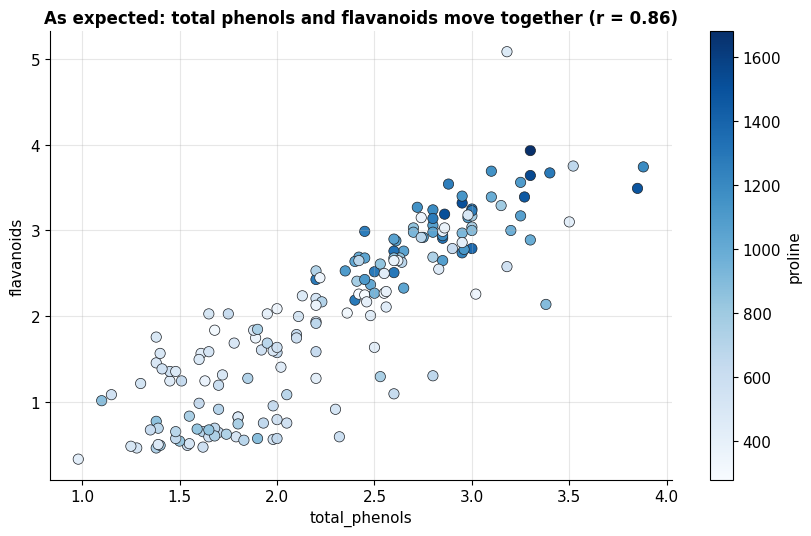

Pearson  correlation total_phenols vs flavanoids: r = 0.865
Spearman (rank) correlation, same pair          : r = 0.879


In [11]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))

sc = ax.scatter(df["total_phenols"], df["flavanoids"],
                c=df["proline"], cmap="Blues",
                s=55, edgecolor=BAS_INK, linewidth=0.5)

r = df["total_phenols"].corr(df["flavanoids"])
ax.set_title(f"As expected: total phenols and flavanoids move together (r = {r:.2f})",
             fontsize=12, fontweight="bold")
ax.set_xlabel("total_phenols")
ax.set_ylabel("flavanoids")
fig.colorbar(sc, ax=ax, label="proline")

plt.tight_layout()
plt.show()

rs = df["total_phenols"].corr(df["flavanoids"], method="spearman")
print(f"Pearson  correlation total_phenols vs flavanoids: r = {r:.3f}")
print(f"Spearman (rank) correlation, same pair          : r = {rs:.3f}")

**Interpretation.** r = 0.865 — a strong, tight, positive, visibly *linear* relationship. Expectation confirmed. The sequential `"Blues"` colormap encodes `proline` (a magnitude with a natural low-to-high direction, which is exactly what sequential maps are for); the darker points lean towards the top-right, hinting that high-phenol wines also tend to be high-proline (r ≈ 0.5 against each axis — real, but far from tight).

Note the honest framing of that r = 0.865. It does **not** mean phenols cause flavanoids. Flavanoids *are* a subclass of phenolic compounds — the two measurements overlap almost by definition. The correlation is real and the causal story is empty.

### What correlation is, and four things it is not

Pearson's r measures **how well a straight line describes the cloud**, on a scale from −1 to +1.

| It cannot see | Consequence | What to do about it |
|---|---|---|
| **Curves.** A perfect U-shape can give r ≈ 0. | r = 0 means "no *linear* trend", never "no relationship". | Look at the scatter. Then compare with **Spearman's rank correlation** (`.corr(method="spearman")`), which catches any monotone trend, straight or not. |
| **Causation.** | r says nothing about direction or mechanism. Both may be driven by a third thing — as we are about to see. | Ask what could plausibly drive both. Only an experiment, or an explicit causal argument, can settle it — never a coefficient. |
| **Outliers.** A single extreme point can create or destroy an r. | The number may be describing two wines rather than 178. | Plot it; then recompute without the suspect points and see whether the finding survives. |
| **Groups.** r is computed on the pooled cloud. | The pooled answer can have the *opposite sign* to every subgroup's answer. | Recompute it **within** each group. Section 7 does exactly that. |

Run the Spearman check as a habit — it costs one keyword. For our phenols pair it is **0.879** against Pearson's **0.865**. Two numbers that close together are evidence that the relationship really is near-straight and is not the work of a handful of extreme wines. When they disagree sharply, believe the picture rather than either number.

One more trap, specific to EDA on labelled data: **never put a categorical code into a correlation.** Our `target` column holds 0, 1, 2 for three cultivars. `df.corr()` will cheerfully return a number for it, and that number silently assumes class 2 is "more" than class 1 in the same way 20 °C is more than 10 °C. It is not — the labels could be shuffled and the "correlation" would change. So we correlate the **13 features only**, and handle the target with `groupby` instead (Section 6). The next cell shows just how badly it goes if you do not.

In [12]:
# Never correlate a categorical code. Here is what it costs you.
print("Group means of color_intensity:",
      df.groupby("cultivar", observed=True)["color_intensity"].mean().round(2).to_dict())
print(f"corr(target, color_intensity)            = {df['target'].corr(df['color_intensity']):+.3f}")

# Exactly the same 178 wines, with the labels of class_0 and class_1 swapped:
relabelled = df["target"].map({0: 1, 1: 0, 2: 2})
print(f"corr(relabelled target, color_intensity) = {relabelled.corr(df['color_intensity']):+.3f}")


Group means of color_intensity: {'class_0': 5.53, 'class_1': 3.09, 'class_2': 7.4}
corr(target, color_intensity)            = +0.266
corr(relabelled target, color_intensity) = +0.759


**What just happened.** Taken at face value, +0.27 reads as "darker wines tend to come from higher-numbered cultivars". But the group means are 5.53 → 3.09 → 7.40: colour intensity *falls* and then *jumps*, so there is no "rises with the class number" pattern to measure in the first place. The correlation averages a fall and a rise into a meaningless compromise.

The second line settles it. Swapping the names of `class_0` and `class_1` — the same wines, the same chemistry, only different arbitrary integers — moves the "correlation" from **+0.27 to +0.76**. A number that changes when you rename your categories is not measuring anything about the wines.

**When one of your two variables is a label, the tool is `groupby`, never `corr`** — which is exactly what Section 6 will do. The heatmap below therefore uses the 13 measured features only.


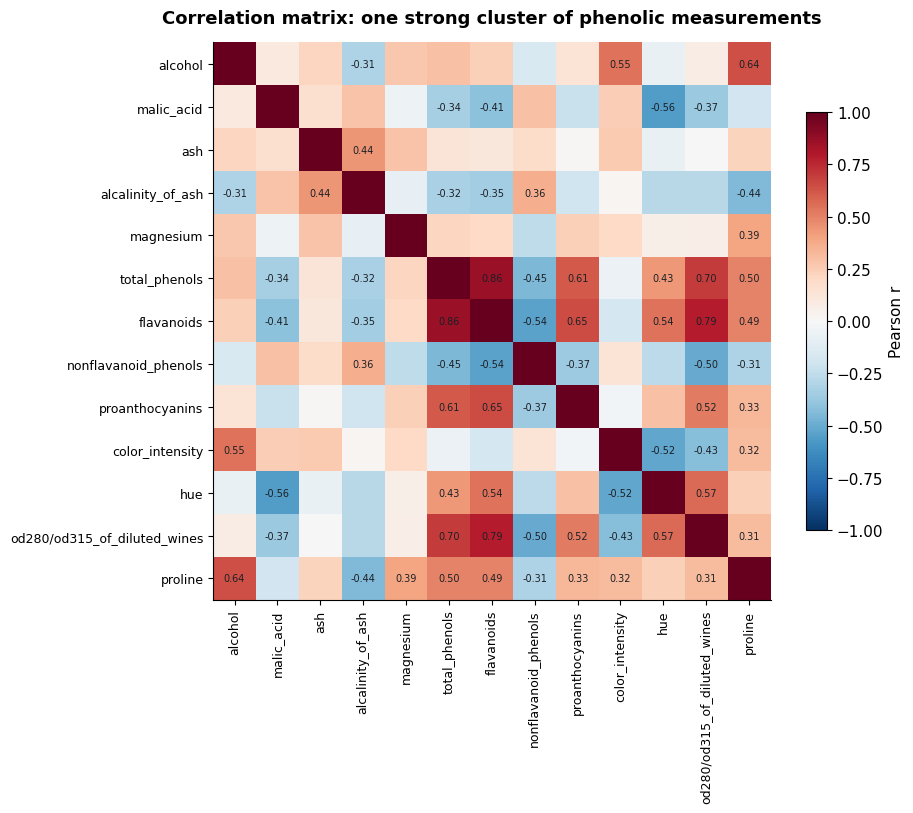

In [13]:
corr = df[FEATURES].corr()      # 13 features only — 'target' deliberately excluded

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=90, fontsize=9)
ax.set_yticks(range(len(FEATURES)), FEATURES, fontsize=9)

# Annotate only the notable cells, so the plot stays readable.
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        v = corr.iat[i, j]
        if i != j and abs(v) >= 0.3:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=7, color=BAS_INK)

ax.set_title("Correlation matrix: one strong cluster of phenolic measurements",
             fontsize=13, fontweight="bold", pad=14)
fig.colorbar(im, ax=ax, shrink=0.75, label="Pearson r")
ax.grid(False)
plt.tight_layout()
plt.show()

**Why a diverging colormap here.** Correlation is a *signed* quantity with a meaningful zero: −0.5 and +0.5 are equally strong but opposite in meaning. A diverging map (`"RdBu_r"`, pinned with `vmin=-1, vmax=1` so white always lands exactly on zero) encodes sign as hue and strength as saturation, so you can read both at a glance. The sequential `"Blues"` map we used for `proline` is the right choice for quantities that only run low-to-high; it would hide the sign here.

**What the matrix says.** Only cells with |r| ≥ 0.3 are annotated, and the annotation count is already the summary: of the 78 unique feature pairs, 34 clear |r| ≥ 0.3 and just 14 clear |r| ≥ 0.5, so most of the matrix stays pale. What stands out is one tight cluster of phenolic chemistry:

| Strongest positive pairs | r |
|---|---|
| `total_phenols` – `flavanoids` | **+0.865** |
| `flavanoids` – `od280/od315_of_diluted_wines` | **+0.787** |
| `total_phenols` – `od280/od315_of_diluted_wines` | **+0.700** |
| `flavanoids` – `proanthocyanins` | **+0.653** |
| `alcohol` – `proline` | **+0.644** |

| Strongest negative pairs | r |
|---|---|
| `malic_acid` – `hue` | **−0.561** |
| `flavanoids` – `nonflavanoid_phenols` | **−0.538** |
| `color_intensity` – `hue` | **−0.522** |

Three or four features are largely measuring the same underlying thing, plus there are some genuine negative relationships. Note that the strongest negative pair (−0.561) is only the *eighth* strongest pair overall by absolute value — the positive phenolic cluster dominates this matrix.

> ⚠️ **Why strong feature–feature correlation matters later.** When two features carry nearly the same information (**multicollinearity**), a linear model can split the credit between them almost arbitrarily: one gets a big positive coefficient, the other a big negative one, the predictions stay fine, and the coefficients become uninterpretable — flipping sign if you refit on slightly different data. Predictive accuracy survives; *explanation* does not. So when you read "feature X has a coefficient of −2.3, therefore X is protective" in Notebook 12 and beyond, check the correlation matrix first. This heatmap is the thing that tells you whether the interpretation is safe.

### Exercise 10.2 — Rank the correlations, then explain the top one

1. From `corr`, extract every **unique** feature pair (no self-pairs, no duplicated mirror-image pairs) with its r. How many pairs should there be?
2. Print the five pairs with the largest **absolute** correlation, keeping the sign visible.
3. Print the three **most negative** pairs as well — they are easy to lose in an absolute-value ranking.
4. For the strongest pair, give one *non-causal* explanation of why they correlate.

*Hint:* `itertools.combinations(FEATURES, 2)` yields every unordered pair exactly once, and `corr.loc[a, b]` looks each one up. (The matrix-shaped alternative is to mask everything but the strict upper triangle with `np.triu(np.ones(corr.shape), k=1).astype(bool)`.)

In [14]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
from itertools import combinations

pairs = pd.Series({(a, b): corr.loc[a, b] for a, b in combinations(FEATURES, 2)})
print("Unique feature pairs:", len(pairs))          # 13 * 12 / 2

top5 = pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(5)
print("\nFive strongest correlations (by |r|):")
for (a, b), v in top5.items():
    print(f"  {v:+.3f}   {a}  vs  {b}")

print("\nThree most negative correlations:")
for (a, b), v in pairs.sort_values().head(3).items():
    print(f"  {v:+.3f}   {a}  vs  {b}")
```

Output:

```
Unique feature pairs: 78

Five strongest correlations (by |r|):
  +0.865   total_phenols  vs  flavanoids
  +0.787   flavanoids  vs  od280/od315_of_diluted_wines
  +0.700   total_phenols  vs  od280/od315_of_diluted_wines
  +0.653   flavanoids  vs  proanthocyanins
  +0.644   alcohol  vs  proline

Three most negative correlations:
  -0.561   malic_acid  vs  hue
  -0.538   flavanoids  vs  nonflavanoid_phenols
  -0.522   color_intensity  vs  hue
```

**Reasoning.** With 13 features there are 13 × 12 / 2 = **78** unique pairs. `combinations` is what keeps each pair exactly once: loop over all 169 cells of the matrix instead and you get the thirteen 1.0 values on the diagonal plus every real pair twice, which quietly doubles the weight of everything you then rank. (The pandas idiom `corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()` does the same job matrix-style, and is what you would use to blank out the upper triangle of the heatmap itself.)

Sorting by `.abs()` and *reindexing* — rather than sorting the absolute values themselves — keeps the **sign** in the printed output, which matters a great deal: the top five here are all positive, so an absolute-value ranking alone would have quietly hidden the fact that this dataset also contains three fairly strong negative relationships. The strongest of them (`malic_acid` vs `hue`, −0.561) only ranks eighth by |r|. Whenever you summarise a correlation matrix, report both ends.

**A non-causal explanation for the top pair.** Flavanoids are one *category of* phenolic compound, and `total_phenols` is a measurement of all phenols together. The two columns therefore share much of the same substance by construction: increasing flavanoids mechanically increases total phenols because flavanoids are part of the total. This is **measurement overlap**, not one variable influencing the other — closer to correlating "height in cm" with "height in inches" than to a causal claim. It is also a warning: feeding both to a linear model gives it two near-copies of one signal.
</details>

## 6. Split by group — which features separate the cultivars? (checklist step 6)

This is the step where EDA starts to look like machine learning. The question "which chemical measurements tell the three cultivars apart?" is exactly the question a classifier answers — except here you answer it by hand, with `groupby`, so that you will recognise whether the model's answer is sensible.

In [15]:
grouped = df.groupby("cultivar", observed=True)[FEATURES].mean()
grouped.T.round(2)   # features as rows, cultivars as columns — easier to scan

cultivar,class_0,class_1,class_2
alcohol,13.74,12.28,13.15
malic_acid,2.01,1.93,3.33
ash,2.46,2.24,2.44
alcalinity_of_ash,17.04,20.24,21.42
magnesium,106.34,94.55,99.31
total_phenols,2.84,2.26,1.68
flavanoids,2.98,2.08,0.78
nonflavanoid_phenols,0.29,0.36,0.45
proanthocyanins,1.90,1.63,1.15
color_intensity,5.53,3.09,7.40


**Reading down the column of a `groupby` table.** Look for rows where the three numbers are far apart *relative to how much that feature varies overall*:

- `flavanoids`: 2.98 / 2.08 / 0.78 — a clean staircase. Class 2 has barely a quarter of class 0's flavanoids.
- `proline`: 1115.71 / 519.51 / 629.90 — class 0 stands right out; classes 1 and 2 are closer to each other.
- `color_intensity`: 5.53 / 3.09 / 7.40 — **not** monotone in the class code, and note that class 2 is the *highest*. Remember this row.
- `hue`: 1.06 / 1.06 / 0.68 — useless for separating class 0 from class 1, excellent for spotting class 2.
- `ash`: 2.46 / 2.24 / 2.44 — nearly identical. This feature has almost nothing to say.

"Far apart relative to overall variation" is a comparison we can automate. Here is one way to score it: the spread of the group means, measured in units of the feature's overall standard deviation.

$$\text{separation}(f) = \frac{\max_g \overline{f}_g - \min_g \overline{f}_g}{\operatorname{std}(f)}$$

> ⚠️ **This is a home-made number, not a standard statistic.** We just invented it because it is easy to read; it has no name, no distribution and no p-value, so use it to *rank features inside one table* and nothing else. Do not quote it in a report and do not compare it across datasets. Its respectable cousins measure the same idea properly: **Cohen's *d*** (a difference of means divided by the *pooled within-group* standard deviation) and the **ANOVA F-statistic** (`sklearn.feature_selection.f_classif`), which comes with a p-value attached. Note also what our denominator does: the *overall* standard deviation already contains the between-group spread that the numerator is measuring, so a strongly separating feature inflates its own denominator. With three groups of the sizes we have (59 / 71 / 48) the score cannot exceed about **2.6** even if the groups do not overlap at all, so `flavanoids`' 2.20 is already close to the arithmetic ceiling — worth knowing before you are impressed by the number.

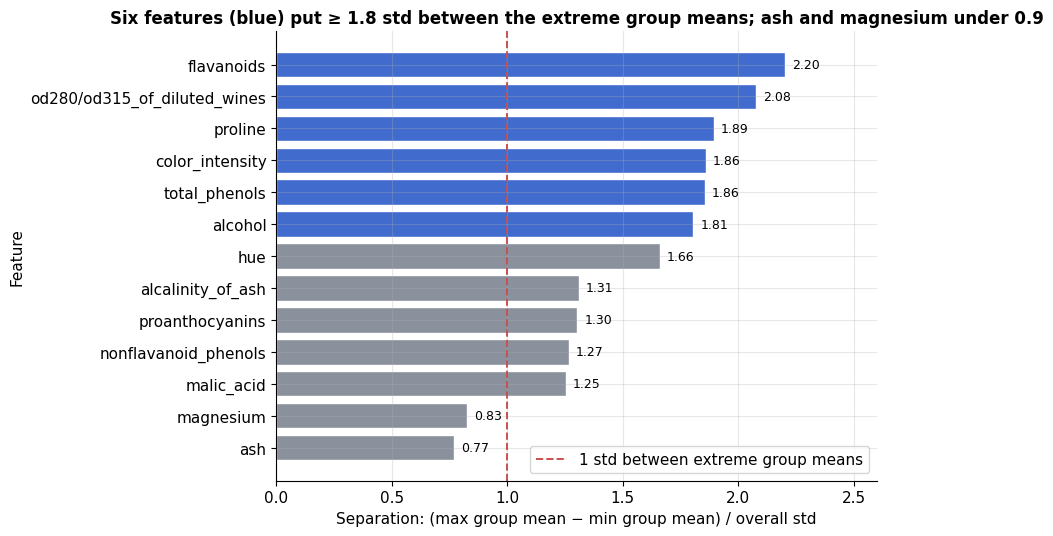

flavanoids                      2.20
od280/od315_of_diluted_wines    2.08
proline                         1.89
color_intensity                 1.86
total_phenols                   1.86
alcohol                         1.81
hue                             1.66
alcalinity_of_ash               1.31
proanthocyanins                 1.30
nonflavanoid_phenols            1.27
malic_acid                      1.25
magnesium                       0.83
ash                             0.77
dtype: float64


In [16]:
separation = ((grouped.max() - grouped.min()) / df[FEATURES].std()).sort_values()

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [BAS_BLUE if s >= 1.8 else BAS_GREY for s in separation.values]
ax.barh(separation.index, separation.values, color=colors, edgecolor="white")
ax.axvline(1.0, color=BAS_RED, linestyle="--", linewidth=1.4,
           label="1 std between extreme group means")

for y, v in enumerate(separation.values):
    ax.text(v + 0.03, y, f"{v:.2f}", va="center", fontsize=9)

ax.set_title("Six features (blue) put ≥ 1.8 std between the extreme group means; ash and magnesium under 0.9",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Separation: (max group mean − min group mean) / overall std")
ax.set_ylabel("Feature")
ax.set_xlim(0, 2.6)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(separation.sort_values(ascending=False).round(2))

**Interpretation — this is a prediction about the model.** The ranking says `flavanoids` (2.20), `od280/od315_of_diluted_wines` (2.08), `proline` (1.89), `color_intensity` (1.86), `total_phenols` (1.86) and `alcohol` (1.81) carry most of the class signal, while `ash` (0.77) and `magnesium` (0.83) carry very little — their group means are less than one standard deviation apart, so the three cultivars' distributions overlap heavily on those axes.

Two caveats you should state whenever you use a score like this:

1. It only looks at **means**. A feature whose groups have identical means but very different spreads would score 0 and still be useful.
2. It looks at **one feature at a time**. Two individually mediocre features can separate perfectly in combination — a diagonal boundary that neither axis sees alone. That is precisely the kind of structure a model finds and a per-feature score cannot.

So treat the ranking as a hypothesis, not a verdict — and **what you do next with it** is the whole value:

- **Look at the distributions**, not just the means, for the features at the top of the list (next cell).
- **Cross-check with a real statistic** if the ranking is going to inform a decision: `f_classif` from `sklearn.feature_selection` scores the same 13 features by ANOVA F and hands you a p-value with it.
- **Write the ranking down as a prediction.** Notebook 11 fits a decision tree to these same 13 columns and prints which features it actually leaned on; Notebook 12 wraps that in a pipeline you can reuse. If the model's ranking and yours disagree, one of you has found something.

Means hide spread, so let us look at the full distributions for the winner and for a runner-up.

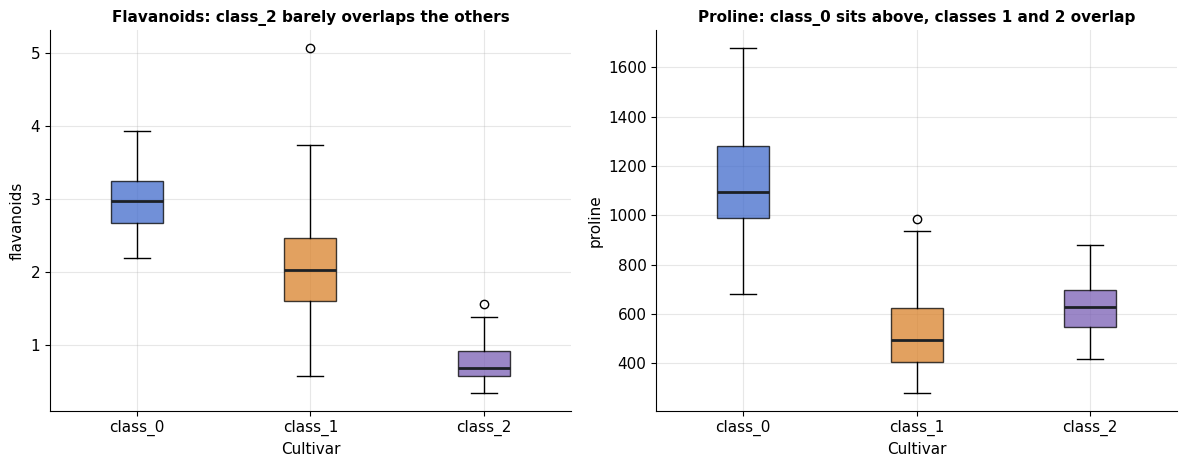

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for ax, col in zip(axes, ["flavanoids", "proline"]):
    groups = [df.loc[df["cultivar"] == c, col].values for c in wine.target_names]
    bp = ax.boxplot(groups, tick_labels=list(wine.target_names), patch_artist=True,
                    medianprops=dict(color=BAS_INK, linewidth=2))
    for patch, c in zip(bp["boxes"], wine.target_names):
        patch.set_facecolor(CULTIVAR_COLORS[c])
        patch.set_alpha(0.75)
    ax.set_xlabel("Cultivar")
    ax.set_ylabel(col)

axes[0].set_title("Flavanoids: class_2 barely overlaps the others", fontsize=11, fontweight="bold")
axes[1].set_title("Proline: class_0 sits above, classes 1 and 2 overlap", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

**Interpretation.** The box plots add what the means could not.

- **`flavanoids`:** class 2's whole box sits below class 0's and class 1's. A single threshold around 1.4 would already isolate most of class 2 — but classes 0 and 1 still overlap substantially, so flavanoids alone cannot finish the job.
- **`proline`:** class 0's box is clearly above the others (mean 1115.7 against 519.5 and 629.9), while classes 1 and 2 sit almost on top of each other. Proline is the feature that peels off class 0.

Put together: `flavanoids` finds class 2, `proline` finds class 0, and what is left is class 1. Two features, three classes, an informal decision tree — **you have just done by hand what Notebook 11's decision tree does by optimisation** — and when that tree prints its feature importances, `flavanoids`, `proline` and `od280/od315` should be at the top of the list. That is the whole point of doing EDA first: the model should confirm your intuition, and when it does not, one of you is wrong and it is worth finding out which.

### Exercise 10.3 — Find the least useful feature, and prove it

The separation score named `ash` as the weakest feature. Back that up with a picture:

1. Print the per-cultivar mean **and** std of `ash` and of `flavanoids`.
2. Draw the two box plots side by side, on the same colour scheme as above.
3. State in one sentence what "useless for this task" looks like on a box plot.

In [18]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
stats = df.groupby("cultivar", observed=True)[["ash", "flavanoids"]].agg(["mean", "std"]).round(2)
print(stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, col in zip(axes, ["ash", "flavanoids"]):
    groups = [df.loc[df["cultivar"] == c, col].values for c in wine.target_names]
    bp = ax.boxplot(groups, tick_labels=list(wine.target_names), patch_artist=True,
                    medianprops=dict(color=BAS_INK, linewidth=2))
    for patch, c in zip(bp["boxes"], wine.target_names):
        patch.set_facecolor(CULTIVAR_COLORS[c])
        patch.set_alpha(0.75)
    ax.set_xlabel("Cultivar")
    ax.set_ylabel(col)

axes[0].set_title("Ash: three boxes on top of each other → no signal",
                  fontsize=11, fontweight="bold")
axes[1].set_title("Flavanoids: boxes step downwards → strong signal",
                  fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()
```

**Reasoning.** The group means for `ash` are 2.46 / 2.24 / 2.44 while the overall standard deviation is 0.27 — the extremes are only about 0.21 apart, i.e. **less than one standard deviation**, which is exactly the 0.77 separation score. On the plot the three boxes sit almost at the same height with heavily overlapping whiskers. For `flavanoids` the means are 2.98 / 2.08 / 0.78 against an overall std of 1.00, giving a separation of 2.20, and the boxes step visibly downwards with only small overlap.

One sentence: *"a useless feature is one whose group box plots are stacked on top of one another — knowing the value tells you almost nothing about which group the sample came from."* Careful, though: useless *for separating these three cultivars* is not the same as useless in general. `ash` might well be the best predictor of some other outcome. Usefulness is always relative to the question.
</details>

## 7. A relationship that survives no scrutiny at all

Time to test a new expectation. Two of our features describe pigment-related chemistry: `flavanoids` (a family of compounds that includes pigments) and `color_intensity`. Chemically, more of the pigment family ought to go with more colour. Let us look at all 178 wines.

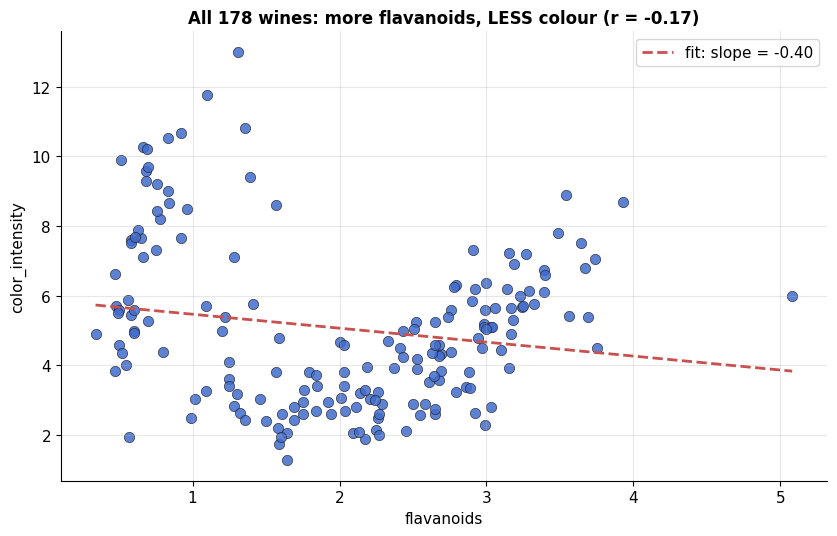

Pooled correlation flavanoids vs color_intensity: r = -0.172


In [19]:
r_all = df["flavanoids"].corr(df["color_intensity"])

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(df["flavanoids"], df["color_intensity"],
           color=BAS_BLUE, s=55, alpha=0.85, edgecolor=BAS_INK, linewidth=0.5)

# Least-squares line through the whole cloud
m, b = np.polyfit(df["flavanoids"], df["color_intensity"], 1)
xs = np.linspace(df["flavanoids"].min(), df["flavanoids"].max(), 50)
ax.plot(xs, m * xs + b, color=BAS_RED, linestyle="--", linewidth=2,
        label=f"fit: slope = {m:+.2f}")

ax.set_title(f"All 178 wines: more flavanoids, LESS colour (r = {r_all:.2f})",
             fontsize=12, fontweight="bold")
ax.set_xlabel("flavanoids")
ax.set_ylabel("color_intensity")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pooled correlation flavanoids vs color_intensity: r = {r_all:.3f}")

### ✍️ Stop here and commit to an answer

The number is r = **−0.17** and the fitted slope is negative. Taken at face value, the finding writes itself:

> *"Across 178 wines, flavanoid content is **negatively** associated with colour intensity: the wines richest in flavanoids are the palest. The effect is weak but the direction is clear — whatever these pigment-family compounds do, they do not make wine darker."*

Before you scroll: **write down whether you believe that**, and what you would do next to check it. Then run the next cell, which changes exactly one thing — it colours each point by the cultivar it came from.

Correlation flavanoids vs color_intensity
  pooled, all 178 wines : -0.172   (Spearman -0.043)
  within class_0        : +0.742   (n = 59)
  within class_1        : +0.379   (n = 71)
  within class_2        : +0.367   (n = 48)


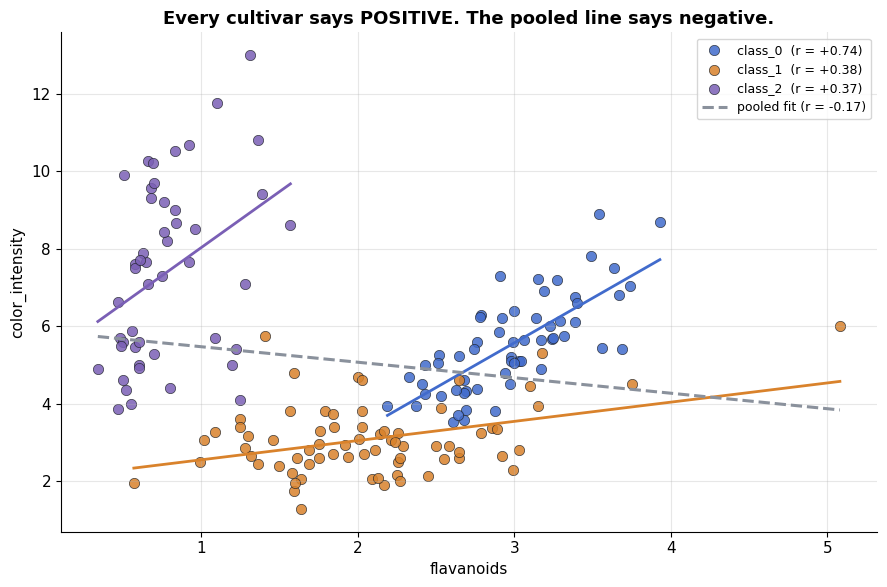

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))

print("Correlation flavanoids vs color_intensity")
print(f"  pooled, all 178 wines : {r_all:+.3f}"
      f"   (Spearman {df['flavanoids'].corr(df['color_intensity'], method='spearman'):+.3f})")

for c in wine.target_names:
    sub = df[df["cultivar"] == c]
    r_c = sub["flavanoids"].corr(sub["color_intensity"])
    print(f"  within {c}        : {r_c:+.3f}   (n = {len(sub)})")

    ax.scatter(sub["flavanoids"], sub["color_intensity"],
               color=CULTIVAR_COLORS[c], s=55, alpha=0.85,
               edgecolor=BAS_INK, linewidth=0.5,
               label=f"{c}  (r = {r_c:+.2f})")

    mi, bi = np.polyfit(sub["flavanoids"], sub["color_intensity"], 1)
    xi = np.linspace(sub["flavanoids"].min(), sub["flavanoids"].max(), 30)
    ax.plot(xi, mi * xi + bi, color=CULTIVAR_COLORS[c], linewidth=2)

# The pooled line, kept for comparison
ax.plot(xs, m * xs + b, color=BAS_GREY, linestyle="--", linewidth=2.2,
        label=f"pooled fit (r = {r_all:+.2f})")

ax.set_title("Every cultivar says POSITIVE. The pooled line says negative.",
             fontsize=13, fontweight="bold")
ax.set_xlabel("flavanoids")
ax.set_ylabel("color_intensity")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

### The reveal

Look at the numbers, not the prose:

| Subset | r |
|---|---|
| Pooled, all 178 wines | **−0.17** |
| within `class_0` (n = 59) | **+0.74** |
| within `class_1` (n = 71) | **+0.38** |
| within `class_2` (n = 48) | **+0.37** |

**Every single cultivar shows a positive relationship** — strongly so in class 0 — while the pooled figure is negative.

Be precise about what went wrong here, because it was not the arithmetic. The pooled r = −0.17 is correctly computed, and it correctly describes the pooled cloud. What is wrong is the *sentence* built on it: read as a claim about wines — "wines richer in flavanoids are paler" — it has the **wrong sign for every group in the data**.

Notice as well how thin that evidence was even before we split it. r = −0.17 accounts for under **3 %** of the variation in colour intensity (r² = 0.03), and the rank-based Spearman correlation printed above is **−0.04** — essentially nothing. "The effect is weak but the direction is clear" was never warranted: claiming a direction from a near-zero r is a second, independent mistake, and one you could have caught without any grouping at all.

**Why it happens.** `cultivar` is a **confounding grouping variable**: it influences *both* measurements at once, so it manufactures an association between them that has nothing to do with either one acting on the other.

| | mean flavanoids | mean color_intensity |
|---|---|---|
| `class_0` | 2.98 | 5.53 |
| `class_1` | 2.08 | **3.09** |
| `class_2` | **0.78** | **7.40** |

Read those three group *positions* as three points: (2.98, 5.53), (2.08, 3.09), (0.78, 7.40). They scatter downhill — chiefly because `class_2` is the low-flavanoid, very dark group while `class_1` is mid-flavanoid and the palest of the three. A single line through all 178 wines has to account for the wide gaps **between** those clusters as well as the trend **inside** them, and here the between-group spread is much the larger of the two, so it wins and it sets the sign. That is the mechanism: pool groups that differ in *both* variables, and the between-group pattern can overwhelm — and reverse — the within-group one. When it reverses a sign like this, the phenomenon has a name: **Simpson's paradox**.

Two consequences worth keeping.

- **Neither number is "the" answer — they answer different questions.** *"Across this whole collection, are high-flavanoid wines darker?"* → no, weakly. *"Within one cultivar, does more flavanoid go with more colour?"* → yes, clearly. Only the second is a statement about wine chemistry; the first is largely a statement about which cultivars happened to be sampled. Deciding which question you are asking is a design choice, not a calculation.
- **The paradox does not need a sign flip to bite.** Groups that merely *disagree* — one positive, one flat, one negative — already make the pooled number a description of nothing in particular. You will meet exactly that in the capstone (Notebook 14), where two cities have opposite temperature–rainfall relationships and the global correlation describes neither of them.

**How you avoid it.** Not by being cleverer with the correlation — by asking, of every aggregate number, *"is this pooled over groups that differ?"* Then re-computing it within the groups. That is checklist step 6, and it is the step people skip.

Notice what the *univariate* section already whispered: the `flavanoids` histogram had two humps. A multi-modal distribution is a mixture of populations announcing itself. We were warned; we just had not yet asked the question in a way that could hear the warning.

> 🌍 **Why this matters beyond wine.** The same arithmetic produces the famous real cases: a university whose overall admission rate favours men while every individual department favours women; a treatment that looks worse overall because it was given to the sicker patients; a pay-gap analysis that shrinks or grows depending on whether you pool job levels. In each case the pooled number is *arithmetically correct* and *substantively backwards*. There is no test that flags this for you. Only the question "grouped by what?" does.

### Exercise 10.4 — Does it happen twice?

`malic_acid` and `color_intensity` are a second suspicious pair.

1. Compute the pooled correlation between them.
2. Compute the correlation **within** each cultivar.
3. Draw one scatter plot coloured by cultivar with a fitted line per group plus the pooled line, following the style of the chart above.
4. Say in one sentence whether the pooled number is trustworthy.

In [21]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
a, b_ = "malic_acid", "color_intensity"
r_pooled = df[a].corr(df[b_])
print(f"pooled r = {r_pooled:+.3f}")

fig, ax = plt.subplots(figsize=(9, 6))

for c in wine.target_names:
    sub = df[df["cultivar"] == c]
    r_c = sub[a].corr(sub[b_])
    print(f"within {c}: r = {r_c:+.3f}")
    ax.scatter(sub[a], sub[b_], color=CULTIVAR_COLORS[c], s=55, alpha=0.85,
               edgecolor=BAS_INK, linewidth=0.5, label=f"{c}  (r = {r_c:+.2f})")
    mi, bi = np.polyfit(sub[a], sub[b_], 1)
    xi = np.linspace(sub[a].min(), sub[a].max(), 30)
    ax.plot(xi, mi * xi + bi, color=CULTIVAR_COLORS[c], linewidth=2)

mp, bp = np.polyfit(df[a], df[b_], 1)
xp = np.linspace(df[a].min(), df[a].max(), 50)
ax.plot(xp, mp * xp + bp, color=BAS_GREY, linestyle="--", linewidth=2.2,
        label=f"pooled fit (r = {r_pooled:+.2f})")

ax.set_title("Malic acid vs colour intensity: pooled says +, every cultivar says −",
             fontsize=12, fontweight="bold")
ax.set_xlabel(a)
ax.set_ylabel(b_)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
```

Output:

```
pooled r = +0.249
within class_0: r = -0.258
within class_1: r = -0.203
within class_2: r = -0.162
```

**Reasoning.** The sign flips again, in the other direction this time: pooled **+0.25**, but **−0.26 / −0.20 / −0.16** inside the three cultivars. The mechanism is the same confounder. Class 2 has both the highest mean malic acid (3.33 against 2.01 and 1.93) and by far the highest mean colour intensity (7.40), so that one cluster sits up and to the right of the others and drags a positive line through the pooled cloud — while within each cluster the local trend is mildly negative.

One sentence: *"the pooled +0.25 is not trustworthy — it describes the difference between cultivars, not a relationship between the two chemicals, and every cultivar individually shows the opposite sign."*

Note the honest coda: the within-group correlations here (−0.16 to −0.26) are **weak**, and with 48–71 wines per group they are not strong evidence of much. The trustworthy conclusion is not "the true relationship is negative" but "the pooled number answers a different question than the one I asked". Discovering that a finding dissolves is a real finding.
</details>

## 8. A compact EDA dashboard

Once the investigation is done, compress it. Four panels, one figure — the version you paste into a slide or the top of a report. Every panel title states its **takeaway**, not its contents.

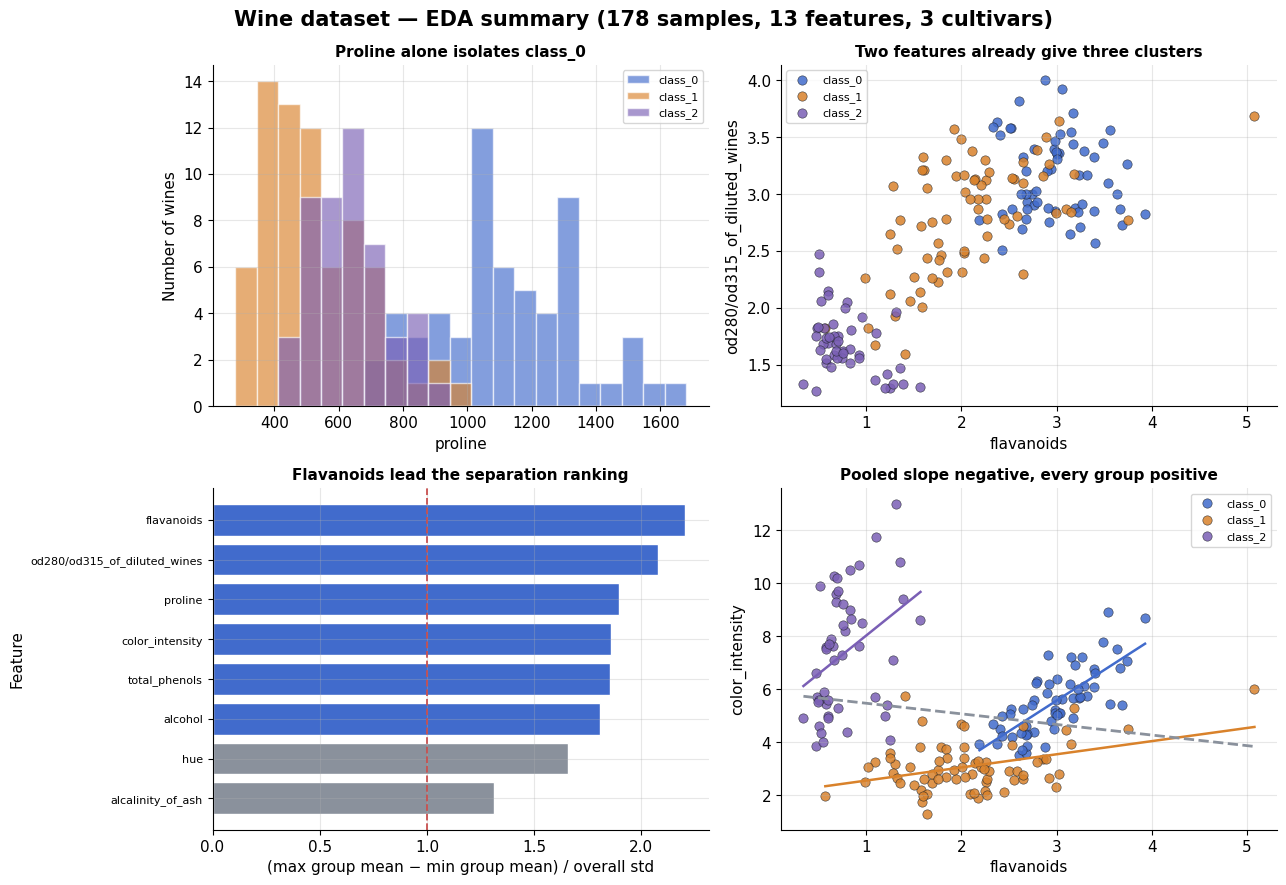

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Wine dataset — EDA summary (178 samples, 13 features, 3 cultivars)",
             fontsize=15, fontweight="bold")

# (0,0) Proline distribution by cultivar
ax = axes[0, 0]
bins = np.linspace(df["proline"].min(), df["proline"].max(), 22)
for c in wine.target_names:
    ax.hist(df.loc[df["cultivar"] == c, "proline"], bins=bins, alpha=0.65,
            color=CULTIVAR_COLORS[c], edgecolor="white", label=c)
ax.set_title("Proline alone isolates class_0", fontsize=11, fontweight="bold")
ax.set_xlabel("proline")
ax.set_ylabel("Number of wines")
ax.legend(fontsize=8)

# (0,1) Two strong features -> three visible clusters
ax = axes[0, 1]
for c in wine.target_names:
    sub = df[df["cultivar"] == c]
    ax.scatter(sub["flavanoids"], sub["od280/od315_of_diluted_wines"],
               color=CULTIVAR_COLORS[c], s=45, alpha=0.85,
               edgecolor=BAS_INK, linewidth=0.4, label=c)
ax.set_title("Two features already give three clusters", fontsize=11, fontweight="bold")
ax.set_xlabel("flavanoids")
ax.set_ylabel("od280/od315_of_diluted_wines")
ax.legend(fontsize=8)

# (1,0) Separation ranking
ax = axes[1, 0]
top = separation.tail(8)
ax.barh(top.index, top.values,
        color=[BAS_BLUE if v >= 1.8 else BAS_GREY for v in top.values],
        edgecolor="white")
ax.axvline(1.0, color=BAS_RED, linestyle="--", linewidth=1.3)
ax.set_title("Flavanoids lead the separation ranking", fontsize=11, fontweight="bold")
ax.set_xlabel("(max group mean − min group mean) / overall std")
ax.set_ylabel("Feature")
ax.tick_params(axis="y", labelsize=8)

# (1,1) The confounded pair
ax = axes[1, 1]
for c in wine.target_names:
    sub = df[df["cultivar"] == c]
    ax.scatter(sub["flavanoids"], sub["color_intensity"],
               color=CULTIVAR_COLORS[c], s=45, alpha=0.85,
               edgecolor=BAS_INK, linewidth=0.4, label=c)
    mi, bi = np.polyfit(sub["flavanoids"], sub["color_intensity"], 1)
    xi = np.linspace(sub["flavanoids"].min(), sub["flavanoids"].max(), 30)
    ax.plot(xi, mi * xi + bi, color=CULTIVAR_COLORS[c], linewidth=1.8)
ax.plot(xs, m * xs + b, color=BAS_GREY, linestyle="--", linewidth=2)
ax.set_title("Pooled slope negative, every group positive", fontsize=11, fontweight="bold")
ax.set_xlabel("flavanoids")
ax.set_ylabel("color_intensity")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Takeaway per panel — this is the caption you would actually write.**

1. **Top-left.** Proline splits `class_0` from the rest almost on its own: its distribution barely overlaps the other two above ~1000. Classes 1 and 2 are indistinguishable on this axis.
2. **Top-right.** `flavanoids` × `od280/od315` — the two highest-scoring features — already produce three visually separable clouds. A classifier on just these two columns would do well, which is a concrete, testable prediction for Notebook 11.
3. **Bottom-left.** The separation ranking: `flavanoids` (2.20) and `od280/od315` (2.08) lead; the dashed line marks one standard deviation between the extreme group means, and everything shown here clears it.
4. **Bottom-right.** The trap. Three positive within-group slopes, one negative pooled slope (dashed grey). Keep this panel in the deck; it is the one that stops someone quoting the pooled correlation in a meeting.

> 💡 A dashboard is a *summary of a completed investigation*, never a substitute for doing one. Four panels that took twenty minutes of thinking beat forty panels generated in one line.

### Exercise 10.5 — Debug me 🐞

A colleague sends you the cell below. It runs without any error, prints two clean numbers, and the conclusion in the comments sounds reasonable. **It is wrong twice.**

Run it, then find both problems before reading the solution. (Hint: the checklist has seven steps and this analysis started at step 4. Also read the comment on the last line very carefully — one of the bugs is not in the code at all.)

In [23]:
def load_lab_export():
    """Simulate the CSV the lab actually sends us.

    Note from the lab's data dictionary:
        'Instrument dropouts in the magnesium channel are coded -999.'
    """
    export = df[FEATURES].copy()
    rng = np.random.default_rng(7)
    dropouts = rng.choice(export.index, size=12, replace=False)
    export.loc[dropouts, "magnesium"] = -999
    return export

lab = load_lab_export()

# --- the colleague's analysis ---------------------------------------------
mean_mg = lab["magnesium"].mean()
r_mg_alc = lab["magnesium"].corr(lab["alcohol"])

print(f"Average magnesium: {mean_mg:.2f}")
print(f"Correlation magnesium vs alcohol: r = {r_mg_alc:.3f}")

# Conclusion: average magnesium is around 26, and since r is essentially 0,
# alcohol content has no effect on the magnesium level of a wine.

Average magnesium: 25.56
Correlation magnesium vs alcohol: r = 0.055


<details>
<summary>💡 Click to reveal the solution</summary>

**Bug 1 — the sentinel value was never handled (a code bug).** The data dictionary says `-999` means "no reading", but pandas has no way to know that: `-999` is a perfectly good float, so `.mean()` and `.corr()` treat twelve missing measurements as twelve wines with catastrophically negative magnesium. Twelve poisoned rows out of 178 drag the mean from ~99.6 down to ~25.6 and crush the correlation from ~0.25 to ~0.06. Note that nothing crashed and nothing warned — **the most dangerous bugs in data analysis produce plausible numbers.** The fix is checklist step 3: convert sentinels to `NaN` *before* computing anything, and let pandas skip them.

**Bug 2 — the conclusion states causation (a reasoning bug).** "Alcohol content has **no effect on** the magnesium level" is a causal claim, and a correlation coefficient cannot support one in either direction. Even had r genuinely been 0.00, the honest sentence is "we see no *linear association* in this sample" — which still leaves room for a curved relationship, a group-dependent one (Section 7!), or a real effect masked by a confounder. Causal language is the single most common way a correct calculation becomes a false statement.

```python
lab_clean = lab.replace(-999, np.nan)

print("Missing magnesium readings recovered:", int(lab_clean["magnesium"].isna().sum()))
print(f"Average magnesium  broken: {lab['magnesium'].mean():8.2f}"
      f"   fixed: {lab_clean['magnesium'].mean():8.2f}")
print(f"r(magnesium, alcohol) broken: {lab['magnesium'].corr(lab['alcohol']):+.3f}"
      f"   fixed: {lab_clean['magnesium'].corr(lab_clean['alcohol']):+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].scatter(lab["magnesium"], lab["alcohol"], color=BAS_RED, s=45,
                edgecolor=BAS_INK, linewidth=0.4)
axes[0].set_title("Before: twelve points at -999 ruin everything",
                  fontsize=11, fontweight="bold")
axes[1].scatter(lab_clean["magnesium"], lab_clean["alcohol"], color=BAS_GREEN, s=45,
                edgecolor=BAS_INK, linewidth=0.4)
axes[1].set_title("After: a weak positive association is visible",
                  fontsize=11, fontweight="bold")
for ax in axes:
    ax.set_xlabel("magnesium")
axes[0].set_ylabel("alcohol (% vol)")
plt.tight_layout()
plt.show()
```

**Reasoning.** `.replace(-999, np.nan)` turns the sentinels into genuine missing values; `.mean()` and `.corr()` then ignore them automatically, giving mean ≈ **99.63** (against the uncorrupted dataset's 99.74 — we lost 12 readings, not the truth) and r ≈ **+0.25** (against 0.27 uncorrupted). The corrected conclusion: *"in these 178 wines, magnesium and alcohol show a weak positive linear association (r ≈ 0.25); this describes co-occurrence in this sample only, and we make no claim about cause."*

The "before" scatter plot is also the cheapest possible detector. Twelve points parked at x = −999 are impossible to miss visually, and invisible in a mean. **Plot before you summarise.**
</details>

## 9. The checklist, as code

Steps 2 and 3 — structure and sanity — are identical on every dataset you will ever open, so they should not cost you any thinking. Here they are as a function you can paste into a new project.

The principle: **automate the mechanical steps so your attention is free for the judgement calls.** Steps 4–7 — what a shape means, which grouping to split by, what is worth writing down — is where you actually earn your keep, and none of it automates.


In [24]:
from sklearn.datasets import load_breast_cancer


def first_look(features, labels=None):
    """Checklist steps 2 and 3 for any table: structure first, then sanity."""
    dtype_counts = {k: int(v) for k, v in features.dtypes.astype(str).value_counts().items()}
    print(f"shape           : {features.shape[0]} rows x {features.shape[1]} feature columns")
    print(f"dtypes          : {dtype_counts}")
    print(f"missing cells   : {int(features.isna().sum().sum())}"
          f"    |  duplicate rows: {int(features.duplicated().sum())}")

    num = features.select_dtypes("number")
    print(f"contains a <= 0 : {[c for c in num if (num[c] <= 0).any()] or 'no column does'}")
    print(f"sentinel hunt   : {[c for c in num if num[c].isin([-999, 9999]).any()] or 'none found'}")

    typical = num.abs().median().replace(0, np.nan).dropna()
    ratio = typical.max() / typical.min()
    verdict = "SCALE BEFORE MODELLING" if ratio > 100 else "comparable scales"
    print(f"scale span      : typical value {typical.min():.3g} ({typical.idxmin()}) "
          f"... {typical.max():.3g} ({typical.idxmax()})  -> ratio {ratio:,.0f}, {verdict}")

    if labels is not None:
        counts = {str(k): int(v) for k, v in labels.value_counts().sort_index().items()}
        print(f"class balance   : {counts}")
        print(f"majority baseline: {max(counts.values()) / len(labels):.1%} accuracy, for free")


print("--- wine: the table we just spent an hour on -------------------------------")
first_look(df[FEATURES], df["cultivar"])

# The point of a checklist is that it travels. A table we have never opened:
cancer = load_breast_cancer(as_frame=True)
print("\n--- breast cancer: never seen before, same one line of work ----------------")
first_look(cancer.data, cancer.target.map(dict(enumerate(cancer.target_names))))


--- wine: the table we just spent an hour on -------------------------------
shape           : 178 rows x 13 feature columns
dtypes          : {'float64': 13}
missing cells   : 0    |  duplicate rows: 0
contains a <= 0 : no column does
sentinel hunt   : none found
scale span      : typical value 0.34 (nonflavanoid_phenols) ... 674 (proline)  -> ratio 1,981, SCALE BEFORE MODELLING
class balance   : {'class_0': 59, 'class_1': 71, 'class_2': 48}
majority baseline: 39.9% accuracy, for free

--- breast cancer: never seen before, same one line of work ----------------
shape           : 569 rows x 30 feature columns
dtypes          : {'float64': 30}
missing cells   : 0    |  duplicate rows: 0
contains a <= 0 : ['mean concavity', 'mean concave points', 'concavity error', 'concave points error', 'worst concavity', 'worst concave points']
sentinel hunt   : none found
scale span      : typical value 0.00319 (fractal dimension error) ... 686 (worst area)  -> ratio 215,406, SCALE BEFORE MODELLING
c

**Two tables, one function call each.** For the wine data it reproduces by machine what Sections 3 and 4 established by hand: nothing missing, no duplicates, no sentinels, a two-thousand-fold scale span that demands scaling, and a 39.9 % baseline to beat.

The breast-cancer table we have never opened, and the same function immediately raises two things worth chasing:

- **Six columns contain exact zeros.** For a *concavity* measurement zero is physically meaningful — a perfectly convex outline — so this is probably fine. But "probably fine" is a question for whoever did the measuring, and now it is on the list instead of in the model. A sentinel `0` hides in exactly this spot.
- **A 215,000-fold scale span**, from `fractal dimension error` near 0.003 to `worst area` near 686. Any distance-based model fitted to the raw columns would be a model of area and nothing else.
- And a **62.7 % majority baseline**, so "our model is 90 % accurate" means considerably less here than the same sentence would on the wine data.

Four useful facts about an unfamiliar dataset for the price of one call — which is why the mechanical part of the checklist is worth having as code. Note equally carefully what the function *cannot* do: it does not know that a bimodal histogram means a mixture of groups, it cannot tell you what one row represents, and it will never ask "grouped by what?" on your behalf. Steps 4 to 7 stay yours.


## 10. Writing it up (checklist step 7)

An EDA that lives only in notebook outputs has not finished. The deliverable is a short, honest written record in three parts. Here is ours.

### What we learned

1. **The table.** 178 wine samples from one Italian region, three cultivars, 13 numeric chemical features, no missing values and no duplicates. One row is one physical sample. Feature scales differ by three orders of magnitude (`hue` ≈ 1, `proline` ≈ 750), so any distance-based or gradient-based model needs scaling.
2. **Distributions.** Mostly well-behaved. `magnesium` (skew 1.10) and `malic_acid` (1.04) have right tails; `ash` barely varies at all. `flavanoids` is **bimodal**, which in hindsight was the data announcing that it is a mixture of groups.
3. **Class balance.** 59 / 71 / 48 → 33.1 % / 39.9 % / 27.0 %. Mildly unbalanced; the majority-class baseline is 39.9 % accuracy, so that is the number any model must beat before we call it useful.
4. **Redundancy.** `total_phenols`, `flavanoids` and `od280/od315` correlate at 0.70–0.87 — largely one underlying signal measured three ways. Fine for prediction, dangerous for interpreting coefficients.
5. **Signal.** `flavanoids` (separation 2.20), `od280/od315` (2.08), `proline` (1.89) and `color_intensity` (1.86) separate the cultivars best; `ash` (0.77) and `magnesium` (0.83) barely at all. Informally: proline isolates class 0, flavanoids isolate class 2. Two features and three classes look close to linearly separable.
6. **A confounded pair.** `flavanoids` vs `color_intensity` correlates **−0.17** pooled and **+0.74 / +0.38 / +0.37** within cultivars. Cultivar confounds the pair; the pooled number has the wrong sign. The same reversal happens for `malic_acid` vs `color_intensity`.

### What we would check next

- Whether the redundant phenolic features can be reduced to one component (PCA) without losing class separation.
- Whether the top features separate the classes *in combination* better than individually — i.e. does a 2-D or 3-D view make class 1 vs class 2 clean?
- Whether the mild right skew in `magnesium` and `malic_acid` affects any model we intend to fit, or whether a log transform (Notebook 8) helps.
- Whether a proper effect-size measure — Cohen's *d*, or the ANOVA F-score from `f_classif` — reorders our home-made separation ranking. The ranking is a reading aid, not a statistic.
- Whether the handful of high-`magnesium` and high-`color_intensity` wines are genuine samples or measurement artefacts — a question for the people who collected the data, not for the DataFrame.
- Whether any *other* grouping in this data (vintage, vineyard, instrument, analyst) confounds the relationships we just measured. **We cannot check this, because those columns do not exist.** That is the most important sentence in this section.

### What this data cannot tell us

- **Nothing causal.** Every number here is co-occurrence within 178 samples. We never intervened on anything, so no result licenses "X causes Y" — not even the relationships that survive grouping.
- **Nothing about wine in general.** One region, three cultivars, one collection effort, decades ago. A model trained here would be a model of *this sample*, and its accuracy would say nothing about Chilean Merlot.
- **Nothing about the measurement process.** We have no instrument IDs, no dates, no lab identifiers, no uncertainty estimates. If two cultivars happened to be measured on different machines, the separation we admired could be partly *instrument*, and there is no column that would let us find out.
- **Nothing about who defined the labels.** "class_0/1/2" arrived as ground truth. Somebody decided which cultivar each sample was, and we inherited that decision without seeing it.

> 🌉 **Bridge to Notebook 11.** Everything above was you looking. A model is the same search, automated and made precise: instead of eyeballing which features separate the groups, it *optimises* a rule and *measures* how well the rule generalises. Notebook 11 explains what "learning" and "generalisation" actually mean; Notebook 12 builds the scikit-learn pipeline that turns this table into predictions. You arrive there with a hypothesis (flavanoids + proline + od280 should be enough) and a warning list (scale the features, do not over-interpret correlated coefficients, beat 39.9 % before celebrating). That is what EDA is *for*.

## 11. 🌍 Reflection — what you never plotted, you never noticed

This notebook contained a small trap, and it worked because of an omission rather than an error. The pooled correlation of −0.17 was computed correctly. The scatter plot was drawn correctly. Nothing was buggy. The finding was simply backwards, and it stayed backwards until someone thought to colour the points by group.

Now scale that up. A production model is trained on aggregate data by people under deadline pressure, evaluated with an aggregate metric, and reported as a single number. If nobody disaggregates — by group, by region, by device, by any of the categories the data happens to carry — the model can be excellent on average and reliably wrong for a subgroup, and *the process will never surface it*. This is not hypothetical: it is the standard finding of algorithmic-audit work in face recognition, medical triage, credit scoring and speech recognition. In each case the aggregate number was accurate, and the aggregate number was the problem.

EDA is where that check is cheap. After deployment it is expensive, public, and someone else's harm.

Three things worth carrying out of this notebook:

1. **The pooled number is a choice, not a fact.** Every average is an average *over* something. Naming what you pooled over is part of reporting the number.
2. **The columns you do not have are findings too.** We could not check for instrument confounding because there was no instrument column. Write that down; it is a limit on every conclusion downstream.
3. **Unexamined data becomes an unexamined model.** A model cannot correct a question nobody asked of the data. Whatever structure you did not look for, it will learn — silently, and with confidence.

### 💬 Discuss (5 min)

- Our dataset has three cultivars, so the confounder was sitting in plain sight in a labelled column. **What confounders would be invisible in a dataset of job applications, or of medical images?** Who would have to notice them, and at what point in the project?
- Suppose you found the `flavanoids` result, published the pooled −0.17, and someone else found the reversal six months later. What would you want to have done differently — a different method, or a different *habit*?
- The write-up above lists what the data cannot tell us. Whose job is it to read that list? What happens when a model card has no such section at all?

## 🧠 Key takeaways

1. **EDA is an interrogation, not a plot gallery.** Form an expectation, test it, and take surprises seriously — they are the only things the data can tell you that you did not already believe.
2. **Work the checklist in order:** provenance → structure → sanity → univariate → bivariate → grouped → write-up. Each step protects the next — and the two mechanical steps belong in a function you paste into every new project.
3. **Answer "what is one row?" first.** If you cannot, you are not doing analysis yet.
4. **Read `.describe()` as evidence.** mean vs median reveals skew; std vs mean reveals whether a feature varies enough to matter; min/max catch impossible values; the spread of scales tells you whether you will need to scale.
5. **A multi-modal histogram is a mixture of groups** announcing itself. Believe it.
6. **Check class balance before modelling** — it sets the baseline that any model must beat, and it decides which metrics are meaningful (Notebook 11).
7. **Correlation cannot see curves, causation, outliers or groups.** Never correlate a categorical code as if it were a quantity, and always look at the scatter behind the r.
8. **Strong feature–feature correlation is a warning about interpretation**, not about prediction: coefficients become unstable long before accuracy suffers.
9. **`groupby` on the target is EDA's most useful single line.** Which features separate the groups is exactly the question a classifier answers, so form your own answer first. If you score the features with a formula you invented, label it as home-made and name the standard alternative (Cohen's *d*, ANOVA F).
10. **Re-check every aggregate within groups.** Pooling can reverse a relationship's sign — or hide the fact that the groups flatly disagree with each other (Simpson's paradox). Ask "grouped by what?" of every number you report, and "which question does this number answer?" before you quote it.
11. **Finish in writing:** what we learned / what to check next / what this data cannot tell us. The third part is the one that keeps you honest.

## ✅ Self-assessment

- [ ] I can state, unprompted, the seven steps of the EDA checklist and why the order matters.
- [ ] I can load a bundled scikit-learn dataset into a DataFrame with proper column names and say what one row represents.
- [ ] I can read `.shape`, `.dtypes` and `.describe()` and name three concrete facts each output gives me.
- [ ] I can check for missing values, duplicates and sentinel codes before computing any statistic.
- [ ] I can judge a distribution's shape, centre, spread and skew from a histogram, and say when the median beats the mean.
- [ ] I can compute class balance and state the majority-class baseline accuracy.
- [ ] I can build and read a correlation heatmap, and explain why a diverging colormap centred at zero is right for it.
- [ ] I can list four things Pearson's r cannot see.
- [ ] I can explain why the numeric `target` code must be kept out of `df.corr()`.
- [ ] I can use `groupby` to rank features by how well they separate classes — and name two limitations of such a ranking.
- [ ] I can explain why that ranking is a home-made heuristic rather than a statistic, and name a standard alternative to it.
- [ ] I can recognise Simpson's paradox and describe the routine that catches it.
- [ ] I can turn checklist steps 2–3 into a reusable function and run it on a table I have never opened.
- [ ] I can write up findings in three parts, including an honest statement of what the data cannot tell me.

## 🚀 Next step

Continue with **Notebook 11 — Machine Learning Basics** ([`11_machine_learning_basics.ipynb`](11_machine_learning_basics.ipynb)), where the intuitions you just built by hand — "these features separate the groups", "beat the baseline", "do not over-interpret correlated features" — become the vocabulary of supervised learning: features and targets, training and generalisation, overfitting and the bias–variance trade-off.

Previous: **Notebook 9 — Visualisation with Matplotlib** ([`09_visualization_matplotlib.ipynb`](09_visualization_matplotlib.ipynb)).